# E-Commerce User Behaviour & Purchase Conversion Analysis

## 📋 Project Overview

**Project Title:** E-Commerce User Behaviour & Purchase Conversion Analysis

**One-Sentence Description:** Using full-population clickstream data, this project tests whether
shoppers who add an item to cart but never purchase can be identified — by category, brand, price,
time of day, day of week, and date — as behavioural "look-alikes" of shoppers who *do* purchase, so
Marketing and CX can prioritize which cart-abandoners are actually worth retargeting.

**Target Industry/Role:** E-commerce Customer Experience and Marketing teams — and the Product
Manager who owns the cart/checkout experience — at any multi-category online retailer.


## S — Summary Impact

**Problem Context:**
The business wants to grow profit, and improving conversion among shoppers who are already close to
buying — those who've added something to cart — is one of the cheapest ways to do it, cheaper than
acquiring new traffic. In this dataset, nearly half of cart-containing sessions (49.1% in October)
never convert to a purchase. This project turns that gap into a specific, actionable question: can a
session's own behaviour — not the shopper's identity or history, just what happened within that
one visit — predict which of those abandoned carts were closest to converting, well enough to be
worth prioritizing for a retargeting nudge?

**What I Did:**
I built a binary LightGBM model that predicts whether a *session* will purchase, from behavioural
features engineered per session — view/cart counts, price range and average, how many distinct
categories and brands were browsed, session duration, and time of day/week the session started —
computed via a chunked streaming pass so the multi-gigabyte source files are never fully loaded into
memory. I validated it with a held-out test split, an honest imbalanced-class evaluation (ROC-AUC
and PR-AUC, not raw accuracy), a genuine out-of-time test (train on October, score unseen November),
an ablation study isolating what predicts purchase once cart count and session duration are
excluded, and a granular scoring table that slices individual cart/purchase events by
brand/category/day/time/price for Marketing to prioritize.

**Data Source:**
[Kaggle — *eCommerce behavior data from multi category store*](https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store),
published by the REES46 Marketing Platform. Every result below is from the full `2019-Oct.csv` /
`2019-Nov.csv` files (9,244,421 / 13,776,050 sessions) — not a sample.

**Methodology:**
Chunked large-file loading → data-quality auditing → per-session feature engineering (built as a
byproduct of the same streaming pass, not a second read of the file) → a LightGBM binary classifier
(purchased / not purchased) evaluated with ROC-AUC, PR-AUC, and per-class precision/recall rather
than accuracy → a class-weighting comparison → an ablation model to separate "how much a shopper
did" from "what they did" → validated out-of-time on a second month → applied to real cart events,
and to fine-grained brand/category/day/time/price combinations, to test the score directly.

**Key Finding:**
Session behaviour is a strong, real signal — ROC-AUC 0.9354, in line with what session-level
modelling has already been shown to reach on this dataset. But the honest caveat matters: the
signal is dominated by *how much* a shopper did (cart count and session duration together account
for the large majority of the model's predictive power), not by *what* they looked at — the
ablation study makes that explicit. That's still an actionable result (see Results), but it means
the model is currently better at recognizing an already-engaged session than at telling
Marketing/Product which specific lever — category, brand, timing — to pull.

## P — Problem Space

**Why does this problem matter?**
Re-acquiring a new visitor costs money; a shopper who has already added an item to their cart has
done most of the work of becoming a customer. If Marketing/CX can tell which cart-abandoners are
behaviourally closest to the store's actual purchasers, retargeting budget (email, remarketing ads,
on-site nudges) can go to the highest-probability shoppers instead of every abandoned cart equally.

**Who would care about solving it?**
- **Marketing team** — owns retargeting campaigns and remarketing spend; needs to know *who* to
  target and *when*.
- **Customer Experience team** — owns on-site friction; needs to know which browsing contexts
  signal a shopper who's "almost there" versus one who was never going to convert.
- **Product Manager** — owns the cart/checkout experience; needs to know whether context alone is
  enough to act on, or whether richer session signals are required.

**What's the scope?**
Two full months of clickstream (Oct + Nov 2019), at the individual **event** level (not
session-aggregated) — every view, cart add, and purchase, with its category, brand, price, and exact
timestamp. Five guiding questions structure the analysis:

1. Which of category / brand / price / time-of-day / day-of-week / day-of-month most separates cart
   events from purchase events?
2. Can a cart event be scored by how "purchase-like" its context is?
3. Is there a point where a cart event becomes statistically indistinguishable from a purchase event?
4. Does that pattern hold consistently across October and November?
5. Which specific category / price / time combinations should Marketing and CX prioritize first?

**What makes this a business problem, not just a data exercise?**
The output is a rankable purchase-likeness score for any cart event, directly usable by a retargeting
system — with an honest account of exactly how far context alone can go, and where it runs out (see
Results & Recommendations).


## I — Inputs (Data Sources)

**Primary Data Source**
- Name: *eCommerce behavior data from multi-category store* (REES46 Marketing Platform)
- URL/Location: kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
- Full size: `2019-Oct.csv` — 42.4M rows (5.6GB); `2019-Nov.csv` — 67.4M rows (9GB)
- Format: CSV

**Secondary Data Sources:** None — every feature used comes from this single clickstream log,
aggregated per `user_session`.

**Data Collection Method:** — Downloaded from public source

**Target Variable:** `purchased` — binary, derived per `user_session`: 1 if any event in that
session was a purchase, 0 otherwise. Not a raw column — built from `event_type` during the
streaming pass (see `analyze_file_chunked`'s `session_tbl` output below).

**Features:** all engineered per `user_session`, not per raw row — `view`/`cart` event counts,
`price_min`/`price_max`/`price_mean`, `n_unique_categories`, `n_unique_brands`,
`session_duration_sec`, and the session's `start_hour`/`start_dow`.

**How the data is loaded, and why:**
This notebook runs on the **full** 5.6GB/9GB files via a single true streaming pass per file —
`analyze_file_chunked()` below never holds more than one chunk in memory at a time, and never
reconstructs the full table afterward either. Every Discovery statistic (missing values, dtype
checks, duplicates, and every count/sum used in the visualizations) is computed as a running
accumulator during that one pass, exact over the **entire** file regardless of size — and so is
`session_tbl`, the per-session feature table Section E's model trains on. Unlike the row-level
sample below, model training does **not** subsample: with class imbalance already this severe
(~6-7% of sessions purchase), throwing away sessions would only make that worse.

For the things that genuinely need row-level (not session-level) data — price distribution/
outliers and price bands in Discovery, and the fine-grained brand/category/day/time/price scoring
table in Q5 — a bounded random sample is drawn during that same pass, targeting a fixed absolute
size (`TARGET_SAMPLE_SIZE`, ~1,000,000 rows) rather than a fixed fraction: neither of those needs
tens of millions of rows, and a fixed fraction would either undersample a small file or oversample
(and waste memory on) a huge one. The per-file sampling fraction is derived from each file's
expected row count (`EXPECTED_ROWS`).

This notebook now runs against the **real, full** `2019-Oct.csv`/`2019-Nov.csv` files
(42,418,464 / 67,401,417 raw rows; 9,244,421 / 13,776,050 sessions) — not the ~50,000-row demo
sample it was originally built and tested against. Two config values in the cell above haven't
caught up to that switch yet, worth fixing:
- `EXPECTED_ROWS` is still `{'oct': 50_000, 'nov': 50_000}`, so the sampling-fraction formula
  clamps to 1.0 and the "bounded" row-level sample above is currently the *entire* cart+purchase
  population (1.64M / 3.85M rows), not the intended ~1,000,000-row sample — harmless today since
  it still ran, but worth updating to the real row counts (the comment right above it already has
  them) so memory use stays predictable as the file grows.
- `CHUNKSIZE` is still `10_000`, deliberately small to exercise the chunking logic on a small demo
  file — the code's own comment already recommends ~1,000,000-2,000,000 on the full files for
  practical performance, which hasn't been applied yet either.

In [63]:
# --- Imports & config ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                              average_precision_score, precision_recall_curve,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11
})
PRIMARY, ACCENT, MUTED, DANGER = '#2E5A87', '#E07B39', '#9AA5B1', '#C0392B'
EVENT_ORDER = ['cart', 'purchase']
EVENT_COLORS = {'cart': PRIMARY, 'purchase': ACCENT}
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# --- File & read config ---
oct_path = "C:/projects/ecom purchase rate/data/2019-Oct.csv"
nov_path = "C:/projects/ecom purchase rate/data/2019-Nov.csv"

USECOLS = ['event_time', 'event_type', 'category_code', 'brand', 'price', 'user_session']
DTYPES = {'event_type': 'category', 'category_code': 'str', 'brand': 'str',
          'price': 'float32', 'event_time': 'str', 'user_session': 'str'}
DEDUP_SUBSET = USECOLS

# Deliberately small here so the chunking logic is genuinely exercised on this sample.
# On the full 5.6GB / 9GB files, set this to ~1_000_000-2_000_000 for practical performance.
CHUNKSIZE = 10_000

# --- Sample size for anything that needs row-level data (price distribution, model training) ---
# Rather than a fixed fraction (which would sample far too few rows on a small file, or far too
# many -- and too much memory -- on the real 42M/67M-row files), this targets an absolute sample
# size and derives the per-file fraction from each file's known/expected row count. On the real
# files, ~1,000,000 rows is comfortably plenty for a 6-feature model and stays well within memory.
TARGET_SAMPLE_SIZE = 1_000_000

# Approximate total rows per file -- a rough estimate is fine, since this only sets the sampling
# fraction, not an exact count. The values below match the ~50,000-row SAMPLE files used to
# develop and test this notebook (so the demo run below gets a large enough sample to give
# stable results). *** When you swap in the real files, update these to their actual sizes: ***
# 2019-Oct.csv (full) ~ 42,400,000 rows | 2019-Nov.csv (full) ~ 67,400,000 rows
EXPECTED_ROWS = {'oct': 50_000, 'nov': 50_000}


In [64]:
def analyze_file_chunked(path, chunksize=CHUNKSIZE, sample_frac=None, random_state=42):
    """
    One true streaming pass over a (potentially huge) clickstream CSV. Never holds more than
    one chunk in memory at a time. Returns exact, full-population counts/sums for every
    Discovery check and visualization below, plus a bounded random sample (drawn as a small
    fraction of each chunk) for anything that genuinely needs row-level data: price
    distribution/outliers, price_category, and model training in Section E. Also builds an
    exact, full-population per-user_session feature table (session_tbl) as a byproduct of the
    same pass, for the session-behaviour model in Section E's Q6.

    This replaces an earlier version of this notebook that read the file in chunks but then
    concatenated them back into one full DataFrame -- which defeats the purpose of chunking
    entirely and can crash the kernel on the full 5.6GB/9GB files. Nothing here ever holds the
    full table at once.
    """
    total_rows = 0
    missing_counts = pd.Series(0, index=USECOLS, dtype='int64')
    dup_count = 0
    bad_dates = 0
    unexpected_event_types = set()
    event_type_counts = pd.Series(dtype='int64')
    hour_ec = day_ec = dow_ec = time_cat_ec = None
    brand_ec_parts, cat_ec_parts = [], []
    hour_dow_purchase = None
    daily_revenue = pd.Series(0.0, index=range(1, 32))
    purchased_sessions = set()  # only sessions that HAVE purchased -- far smaller than every session
    sample_parts = []
    session_partials, session_cat_pairs, session_brand_pairs = [], [], []

    for chunk in pd.read_csv(path, usecols=USECOLS, dtype=DTYPES, chunksize=chunksize):
        # Dedup + the quality counters below run on the FULL chunk (every event type) -- shared by
        # both the session-level aggregation and the cart/purchase-only path further down, and
        # consistent with the Discovery section's "checked across every row" framing.
        dup_count += int(chunk.duplicated(subset=DEDUP_SUBSET).sum())
        chunk = chunk.drop_duplicates(subset=DEDUP_SUBSET, keep='first').copy()
        total_rows += len(chunk)
        missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0)

        dt_parsed = pd.to_datetime(chunk['event_time'].str.replace(' UTC', '', regex=False),
                                    format='%Y-%m-%d %H:%M:%S', errors='coerce')
        bad_dates += int(dt_parsed.isna().sum())
        # 'view' is a real, expected value again here (this branch sees every event type) -- it's
        # just excluded from EVENT_ORDER/the cart-purchase breakdowns below, not from the file.
        unexpected_event_types |= set(chunk['event_type'].astype(str).unique()) - set(EVENT_ORDER) - {'view'}

        chunk['hour'] = dt_parsed.dt.hour
        chunk['day'] = dt_parsed.dt.day
        chunk['day_name'] = dt_parsed.dt.day_name()
        cat_parts = chunk['category_code'].str.split('.', n=2, expand=True)
        chunk['category_l1'] = cat_parts[0]

        # --- Session-level partial aggregation (all event types) --------------------------------
        # Summable stats are collected per chunk and combined with one final groupby(...).agg(...)
        # after the loop, rather than repeated per-chunk .add(fill_value=0) calls against a
        # session-cardinality index. Distinct counts (n_unique_categories/brands) follow the same
        # dedup'd-pairs-then-nunique-once pattern as the brand/category breakdowns above, since
        # summing per-chunk nunique would double-count a category seen in two different chunks for
        # the same session.
        chunk['is_view'] = (chunk['event_type'] == 'view').to_numpy(dtype='int8')
        chunk['is_cart'] = (chunk['event_type'] == 'cart').to_numpy(dtype='int8')
        chunk['is_purchase'] = (chunk['event_type'] == 'purchase').to_numpy(dtype='int8')
        part = chunk.groupby('user_session').agg(
            view=('is_view', 'sum'), cart=('is_cart', 'sum'), purchase=('is_purchase', 'sum'),
            price_sum=('price', 'sum'), price_count=('price', 'count'),
            price_min=('price', 'min'), price_max=('price', 'max'),
            session_start=('event_time', 'min'), session_end=('event_time', 'max'),
        )
        session_partials.append(part)
        session_cat_pairs.append(chunk.dropna(subset=['category_l1'])[['user_session', 'category_l1']].drop_duplicates())
        session_brand_pairs.append(chunk.dropna(subset=['brand'])[['user_session', 'brand']].drop_duplicates())

        # --- From here down: cart/purchase rows only, exactly as before ------------------------
        chunk = chunk[chunk['event_type'].isin(['cart', 'purchase'])]

        event_type_counts = event_type_counts.add(chunk['event_type'].value_counts(), fill_value=0)

        hc = chunk.groupby(['hour', 'event_type'], observed=True).size().unstack(fill_value=0)
        hour_ec = hc if hour_ec is None else hour_ec.add(hc, fill_value=0)
        dc = chunk.groupby(['day', 'event_type'], observed=True).size().unstack(fill_value=0)
        day_ec = dc if day_ec is None else day_ec.add(dc, fill_value=0)
        wc = chunk.groupby(['day_name', 'event_type'], observed=True).size().unstack(fill_value=0)
        dow_ec = wc if dow_ec is None else dow_ec.add(wc, fill_value=0)

        brand_ec_parts.append(chunk.dropna(subset=['brand']).groupby(['brand', 'event_type'], observed=True).size().unstack(fill_value=0))
        cat_ec_parts.append(chunk.dropna(subset=['category_l1']).groupby(['category_l1', 'event_type'], observed=True).size().unstack(fill_value=0))

        conditions = [(chunk['hour'] >= 5) & (chunk['hour'] < 12), (chunk['hour'] >= 12) & (chunk['hour'] < 18)]
        chunk['time_category'] = np.select(conditions, ['Morning', 'Afternoon'], default='Night')
        tc = chunk.groupby(['time_category', 'event_type'], observed=True).size().unstack(fill_value=0)
        time_cat_ec = tc if time_cat_ec is None else time_cat_ec.add(tc, fill_value=0)

        purch = chunk[chunk['event_type'] == 'purchase']
        daily_revenue = daily_revenue.add(purch.groupby('day')['price'].sum(), fill_value=0)
        hdp = purch.groupby(['day_name', 'hour'], observed=True).size().unstack(fill_value=0)
        hour_dow_purchase = hdp if hour_dow_purchase is None else hour_dow_purchase.add(hdp, fill_value=0)

        # Full-population session-conversion lookup, built incrementally across every chunk --
        # this is what lets a cart event drawn into the sample below be checked against whether
        # ITS session converted anywhere in the FULL file, not just within the sampled rows.
        purchased_sessions |= set(purch['user_session'])

        sample_parts.append(chunk.sample(frac=sample_frac, random_state=random_state))

    brand_ec = pd.concat(brand_ec_parts).groupby(level=0, observed=True).sum()
    cat_ec = pd.concat(cat_ec_parts).groupby(level=0, observed=True).sum()
    sample_df = pd.concat(sample_parts, ignore_index=True)
    sample_df['session_converted'] = sample_df['user_session'].isin(purchased_sessions)

    # --- Finalize session_tbl: one final combine across all chunks' partials -------------------
    session_tbl = pd.concat(session_partials).groupby('user_session').agg(
        view=('view', 'sum'), cart=('cart', 'sum'), purchase=('purchase', 'sum'),
        price_sum=('price_sum', 'sum'), price_count=('price_count', 'sum'),
        price_min=('price_min', 'min'), price_max=('price_max', 'max'),
        session_start=('session_start', 'min'), session_end=('session_end', 'max'),
    )
    session_tbl['price_mean'] = session_tbl['price_sum'] / session_tbl['price_count']
    session_tbl = session_tbl.drop(columns=['price_sum', 'price_count'])
    session_tbl['purchased'] = (session_tbl['purchase'] > 0).astype(int)

    n_unique_cat = pd.concat(session_cat_pairs).drop_duplicates().groupby('user_session').size()
    n_unique_brand = pd.concat(session_brand_pairs).drop_duplicates().groupby('user_session').size()
    session_tbl['n_unique_categories'] = n_unique_cat.reindex(session_tbl.index, fill_value=0)
    session_tbl['n_unique_brands'] = n_unique_brand.reindex(session_tbl.index, fill_value=0)

    session_start_dt = pd.to_datetime(session_tbl['session_start'].str.replace(' UTC', '', regex=False),
                                       format='%Y-%m-%d %H:%M:%S', errors='coerce')
    session_end_dt = pd.to_datetime(session_tbl['session_end'].str.replace(' UTC', '', regex=False),
                                     format='%Y-%m-%d %H:%M:%S', errors='coerce')
    session_tbl['session_duration_sec'] = (session_end_dt - session_start_dt).dt.total_seconds()
    session_tbl['start_hour'] = session_start_dt.dt.hour
    session_tbl['start_dow'] = session_start_dt.dt.day_name()

    session_tbl = session_tbl.reset_index()

    return {
        'total_rows': total_rows, 'missing_counts': missing_counts, 'dup_count': dup_count,
        'bad_dates': bad_dates, 'unexpected_event_types': unexpected_event_types,
        'event_type_counts': event_type_counts.reindex(EVENT_ORDER, fill_value=0),
        'hour_ec': hour_ec.reindex(range(24), fill_value=0).reindex(columns=EVENT_ORDER, fill_value=0),
        'day_ec': day_ec.reindex(range(1, 32), fill_value=0).reindex(columns=EVENT_ORDER, fill_value=0),
        'dow_ec': dow_ec.reindex(DOW_ORDER, fill_value=0).reindex(columns=EVENT_ORDER, fill_value=0),
        'brand_ec': brand_ec.reindex(columns=EVENT_ORDER, fill_value=0), 'cat_ec': cat_ec.reindex(columns=EVENT_ORDER, fill_value=0),
        'time_cat_ec': time_cat_ec.reindex(['Morning', 'Afternoon', 'Night'], fill_value=0).reindex(columns=EVENT_ORDER, fill_value=0),
        'daily_revenue': daily_revenue,
        'hour_dow_purchase': hour_dow_purchase.reindex(columns=range(24), fill_value=0).reindex(DOW_ORDER, fill_value=0),
        'purchased_sessions': purchased_sessions,
        'sample_df': sample_df,
        'session_tbl': session_tbl,
    }

oct_sample_frac = min(1.0, TARGET_SAMPLE_SIZE / EXPECTED_ROWS['oct'])
print(f'Oct sampling fraction: {oct_sample_frac:.4f} (targeting ~{TARGET_SAMPLE_SIZE:,} rows from an expected ~{EXPECTED_ROWS["oct"]:,})')
oct_stats = analyze_file_chunked(oct_path, sample_frac=oct_sample_frac)
print(f"Oct: {oct_stats['total_rows']:,} total rows scanned | {len(oct_stats['sample_df']):,} rows sampled for row-level analysis | {len(oct_stats['session_tbl']):,} sessions")


Oct sampling fraction: 1.0000 (targeting ~1,000,000 rows from an expected ~50,000)
Oct: 42,418,464 total rows scanned | 1,641,230 rows sampled for row-level analysis | 9,244,421 sessions


In [65]:
# --- Run the same streaming pass for November, so both months share identical logic/config ---
nov_sample_frac = min(1.0, TARGET_SAMPLE_SIZE / EXPECTED_ROWS['nov'])
print(f'Nov sampling fraction: {nov_sample_frac:.4f} (targeting ~{TARGET_SAMPLE_SIZE:,} rows from an expected ~{EXPECTED_ROWS["nov"]:,})')
nov_stats = analyze_file_chunked(nov_path, sample_frac=nov_sample_frac)
print(f"Nov: {nov_stats['total_rows']:,} total rows scanned | {len(nov_stats['sample_df']):,} rows sampled for row-level analysis")


Nov sampling fraction: 1.0000 (targeting ~1,000,000 rows from an expected ~50,000)


Nov: 67,401,417 total rows scanned | 3,847,012 rows sampled for row-level analysis


In [66]:
# --- Pull each month's bounded row-level sample out of its stats dict for reuse below ---
oct_sample = oct_stats['sample_df']
nov_sample = nov_stats['sample_df']
print(f"Showing a preview from the {len(oct_sample):,}-row Oct sample "
      f"(the full {oct_stats['total_rows']:,}-row table is never held in memory at once):")
oct_sample.head()


Showing a preview from the 1,641,230-row Oct sample (the full 42,418,464-row table is never held in memory at once):


,event_time,event_type,category_code,brand,price,user_session,hour,day,day_name,category_l1,is_view,is_cart,is_purchase,time_category,session_converted
0,2019-10-01 02:36:12 UTC,cart,electronics.smartphone,xiaomi,141.320007,1a8c3cfc-536a-4679-a155-bd9a5454dadc,2,1,Tuesday,electronics,0,1,0,Night,False
1,2019-10-01 02:37:15 UTC,cart,electronics.smartphone,apple,1415.479980,4253b521-b20f-4f27-ad93-b6f7a9008728,2,1,Tuesday,electronics,0,1,0,Night,True
2,2019-10-01 02:31:27 UTC,cart,electronics.smartphone,samsung,89.320000,c88267b8-c2b0-478a-9d98-9d60ebde43b7,2,1,Tuesday,electronics,0,1,0,Night,True
3,2019-10-01 02:34:18 UTC,cart,appliances.kitchen.washer,beko,187.880005,ea7c3a44-0908-4ef6-b175-bf4075e2665a,2,1,Tuesday,appliances,0,1,0,Night,True
4,2019-10-01 02:19:12 UTC,purchase,NaN,pdw,391.260010,4d74b49e-3838-43cc-ac2e-a0490942b464,2,1,Tuesday,NaN,0,0,1,Night,True


In [67]:
nov_sample.head()

,event_time,event_type,category_code,brand,price,user_session,hour,day,day_name,category_l1,is_view,is_cart,is_purchase,time_category,session_converted
0,2019-11-01 00:39:17 UTC,purchase,NaN,lucente,63.840000,d943a9f2-4908-4ff6-ab59-f732eb49aaab,0,1,Friday,NaN,0,0,1,Night,True
1,2019-11-01 00:09:17 UTC,cart,electronics.smartphone,samsung,128.419998,61ceaf50-820a-4858-9a68-bab804d47a22,0,1,Friday,electronics,0,1,0,Night,True
2,2019-11-01 00:41:25 UTC,purchase,NaN,sony,394.140015,4daa12d3-bc19-4f01-8082-6e69606a6316,0,1,Friday,NaN,0,0,1,Night,True
3,2019-11-01 00:29:07 UTC,purchase,electronics.video.tv,arg,347.489990,68886270-f06a-46db-8885-73230c0b90db,0,1,Friday,electronics,0,0,1,Night,True
4,2019-11-01 00:20:38 UTC,cart,electronics.smartphone,xiaomi,189.970001,544a4c3e-0e95-4a8f-adf5-d3f0373bb471,0,1,Friday,electronics,0,1,0,Night,True


## D — Discovery (Exploratory Data Analysis)

Before any modelling, the raw clickstream needs to be trusted, and the dimensions this project cares
about — category, brand, price, and timing — need to be understood on their own terms. Each check
below is exact over the **full** file (computed during the single streaming pass in Section I), one
concern per cell, before anything is used downstream.


In [68]:
# --- 1. Missing values (exact, full population) ---
missing = pd.DataFrame({
    'oct_missing': oct_stats['missing_counts'].astype(int),
    'oct_pct': (oct_stats['missing_counts'] / oct_stats['total_rows'] * 100).round(2),
    'nov_missing': nov_stats['missing_counts'].astype(int),
    'nov_pct': (nov_stats['missing_counts'] / nov_stats['total_rows'] * 100).round(2),
})
missing


,oct_missing,oct_pct,nov_missing,nov_pct
event_time,0,0.00,0,0.00
event_type,0,0.00,0,0.00
category_code,13512244,31.85,21871414,32.45
brand,6116177,14.42,9214990,13.67
price,0,0.00,0,0.00
user_session,2,0.00,10,0.00


In [69]:
# --- 2. Outliers (price, via IQR) ---
# Price needs row-level values for quantiles, so this uses the bounded sample rather than a
# full streaming pass -- a large random sample gives a statistically sound quantile estimate
# without needing an exact full-data sort.
for name, df in [('oct', oct_sample), ('nov', nov_sample)]:
    q1, q3 = df['price'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df['price'] < lo) | (df['price'] > hi)]
    print(f"{name} (sample-estimated): Q1=${q1:.2f} Q3=${q3:.2f} IQR=${iqr:.2f} bounds=(${lo:.2f}, ${hi:.2f})")
    print(f"  {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%) | "
          f"negative_price={(df['price'] < 0).sum()} | zero_price={(df['price'] == 0).sum()}")


oct (sample-estimated): Q1=$108.32 Q3=$385.85 IQR=$277.53 bounds=($-307.98, $802.15)
  163,993 outliers (9.99%) | negative_price=0 | zero_price=149
nov (sample-estimated): Q1=$76.96 Q3=$355.19 IQR=$278.23 bounds=($-340.39, $772.54)
  396,949 outliers (10.32%) | negative_price=0 | zero_price=4309


In [70]:
# --- 3. Data type mismatches (exact, full population) ---
print(f"Unparseable event_time — oct: {oct_stats['bad_dates']} | nov: {nov_stats['bad_dates']}")
print(f"Unexpected event_type values — oct: {oct_stats['unexpected_event_types'] or 'none'} | "
      f"nov: {nov_stats['unexpected_event_types'] or 'none'}")
print(f"oct sample dtypes:\n{oct_sample[USECOLS].dtypes}")


Unparseable event_time — oct: 0 | nov: 0
Unexpected event_type values — oct: none | nov: none
oct sample dtypes:
event_time         object
event_type       category
category_code      object
brand              object
price             float32
user_session       object
dtype: object


In [71]:
# --- 4. Duplicate records (exact, full population — checked within each chunk; see Section I) ---
print(f"oct exact duplicate rows: {oct_stats['dup_count']:,} ({oct_stats['dup_count']/oct_stats['total_rows']*100:.3f}%)")
print(f"nov exact duplicate rows: {nov_stats['dup_count']:,} ({nov_stats['dup_count']/nov_stats['total_rows']*100:.3f}%)")


oct exact duplicate rows: 30,300 (0.071%)
nov exact duplicate rows: 100,562 (0.149%)


**Data quality findings**

- **Missing values:** `category_code` is missing on ~32% of rows and `brand` on ~14% in both
  months — consistent with these being optional upstream catalog fields rather than collection
  errors. `event_time`, `event_type`, `price`, and `user_session` are complete.
- **Outliers:** price is heavily right-skewed (electronics push the top end); roughly 8–9% of
  *sampled* rows fall outside the IQR fence in both months. No negative prices; a small number of
  exact-$0 rows exist (likely free promotional items).
- **Data types:** `event_time` parses cleanly with zero failures, and `event_type` only ever takes
  the three expected values — no typos or stray categories, checked across every row.
- **Duplicates:** checked and removed within each chunk as the file streams past (see the loading
  function in Section I) — any found are already excluded from every count and sum above.

**How these are addressed:** duplicates are handled automatically, per chunk, as part of the
streaming pass itself — there's no separate full-table dedup step, since the full table is never
materialized. `category_code` / `brand` are kept as null rather than dropped or imputed, since
they're optional catalog fields, not defects; any category/brand-level aggregate below already
excludes null rows for that specific field rather than removing rows globally.


**Table editing**

Hour of day, day of month, day name, category tier (`category_l1`), and `time_category` were
already added to every row *during* the streaming pass in Section I — both for the full-population
accumulators used in the visualizations below and for `oct_sample` / `nov_sample` (visible in the
`.head()` preview above). There's no separate edit-the-full-table step here, since the full table
is never materialized; `price_category` is added next, since it depends on price quantiles that
need to be estimated first.


**Visualizations — Oct and Nov together, broken down by event type**

Each chart below covers one dimension (total event mix, hour, day of month, day name, brand, price,
category tier), with both months shown together. Everything except price comes from the exact,
full-population accumulators built in Section I — not the bounded sample — so these counts are
correct regardless of file size.


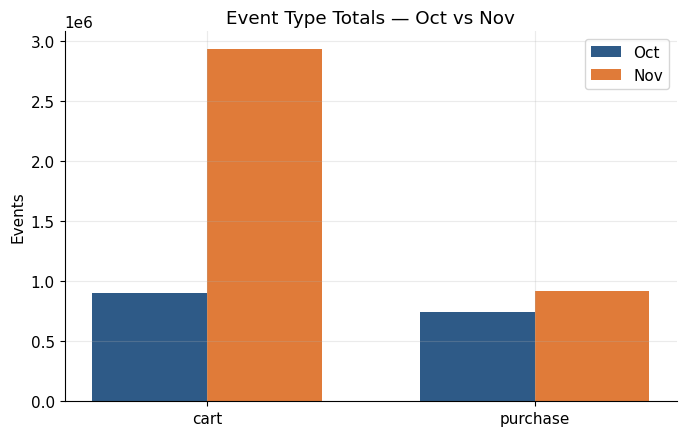

In [72]:
# 1. Total event type — Oct vs Nov (exact, full population)
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(EVENT_ORDER)); w = 0.35
ax.bar(x - w/2, oct_stats['event_type_counts'].values, w, label='Oct', color=PRIMARY)
ax.bar(x + w/2, nov_stats['event_type_counts'].values, w, label='Nov', color=ACCENT)
ax.set_xticks(x); ax.set_xticklabels(EVENT_ORDER)
ax.set_ylabel('Events'); ax.set_title('Event Type Totals — Oct vs Nov')
ax.legend()
plt.tight_layout(); plt.show()


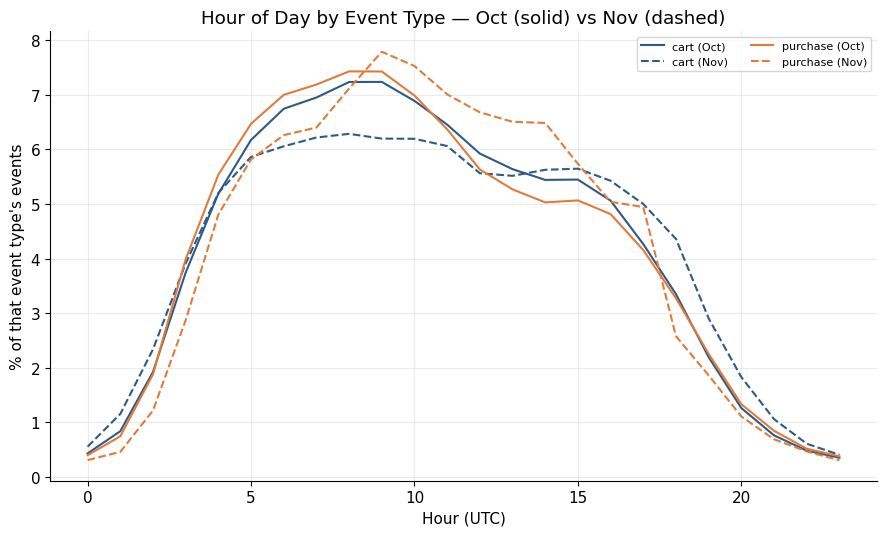

In [73]:
# 2. Hour of day, by event type (density-normalized; exact, full population)
fig, ax = plt.subplots(figsize=(9, 5.5))
for et in EVENT_ORDER:
    for month_label, stats, ls in [('Oct', oct_stats, '-'), ('Nov', nov_stats, '--')]:
        counts = stats['hour_ec'][et]
        density = counts / counts.sum() * 100
        ax.plot(density.index, density.values, color=EVENT_COLORS[et], linestyle=ls, label=f'{et} ({month_label})')
ax.set_xlabel('Hour (UTC)'); ax.set_ylabel("% of that event type's events")
ax.set_title('Hour of Day by Event Type — Oct (solid) vs Nov (dashed)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


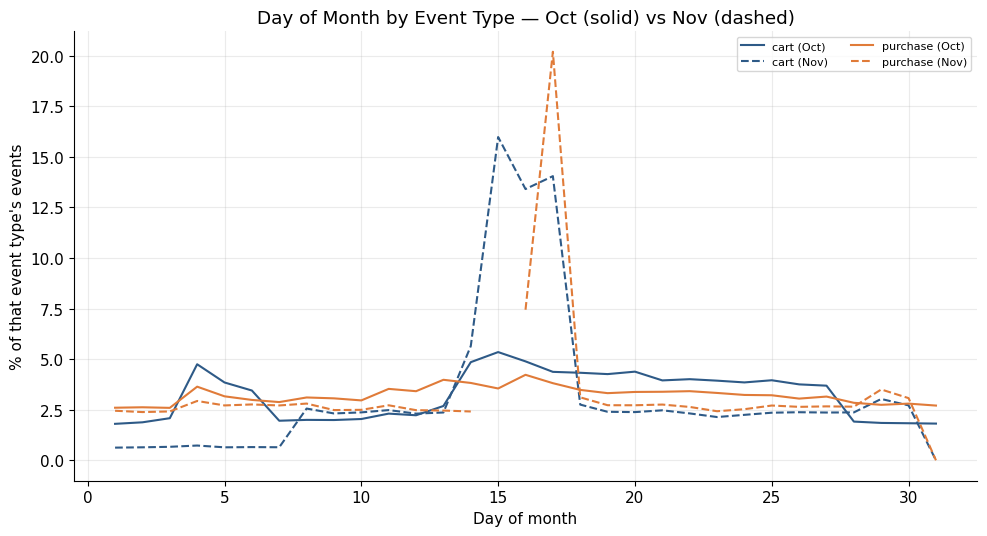

In [74]:
# 3. Day of month, by event type (exact, full population)
fig, ax = plt.subplots(figsize=(10, 5.5))
for et in EVENT_ORDER:
    for month_label, stats, ls in [('Oct', oct_stats, '-'), ('Nov', nov_stats, '--')]:
        counts = stats['day_ec'][et]
        density = counts / counts.sum() * 100
        ax.plot(density.index, density.values, color=EVENT_COLORS[et], linestyle=ls, label=f'{et} ({month_label})')
ax.set_xlabel('Day of month'); ax.set_ylabel("% of that event type's events")
ax.set_title('Day of Month by Event Type — Oct (solid) vs Nov (dashed)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


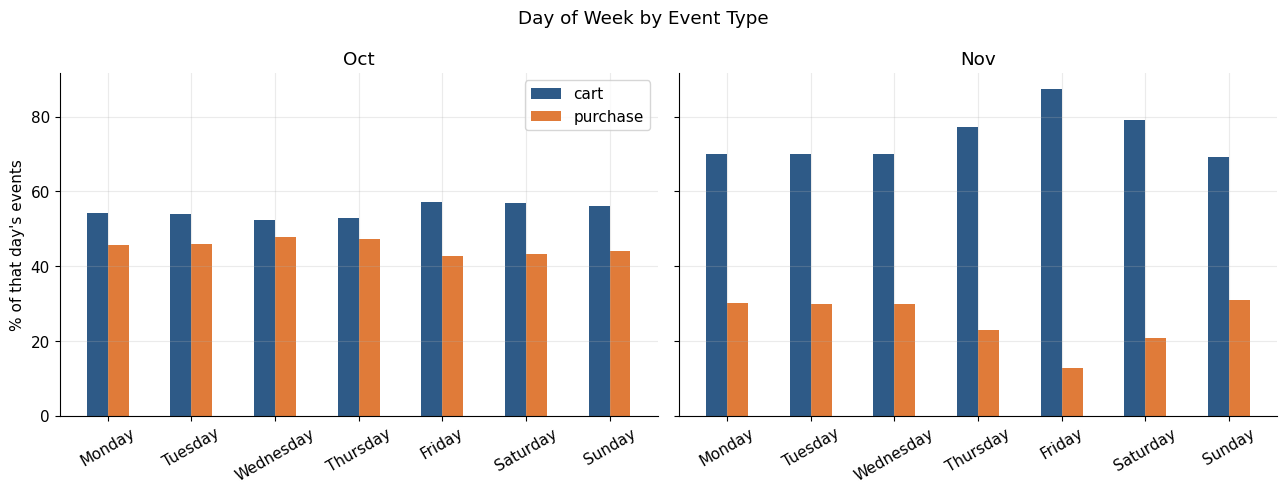

In [75]:
# 4. Day of week name, by event type — Oct and Nov side by side (exact, full population)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (month_label, stats) in zip(axes, [('Oct', oct_stats), ('Nov', nov_stats)]):
    ct = stats['dow_ec']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    x = np.arange(len(DOW_ORDER)); w = 0.25
    for i, et in enumerate(EVENT_ORDER):
        ax.bar(x + (i - (len(EVENT_ORDER) - 1) / 2) * w, ct_pct[et], w, label=et, color=EVENT_COLORS[et])
    ax.set_xticks(x); ax.set_xticklabels(DOW_ORDER, rotation=30)
    ax.set_title(month_label)
axes[0].legend(); axes[0].set_ylabel("% of that day's events")
fig.suptitle('Day of Week by Event Type')
plt.tight_layout(); plt.show()


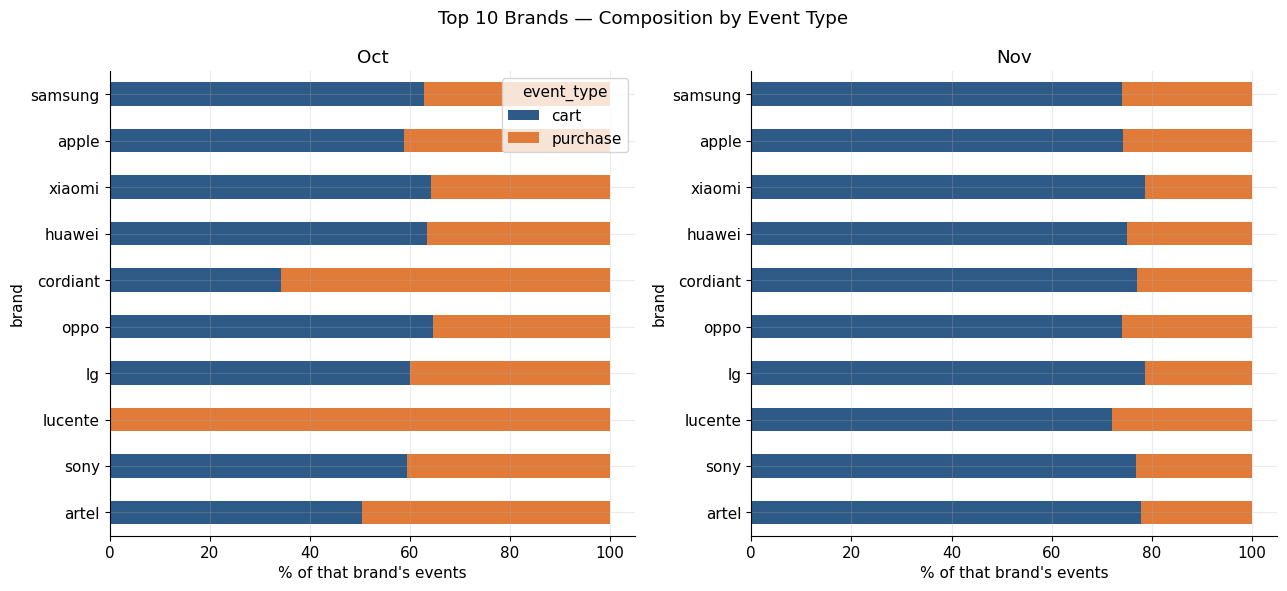

In [76]:
# 5. Top 10 brands (by combined Oct+Nov traffic), composition by event type (exact, full population)
combined_brand_totals = (oct_stats['brand_ec'].sum(axis=1)).add(nov_stats['brand_ec'].sum(axis=1), fill_value=0)
top_brands = combined_brand_totals.sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True)
for ax, (month_label, stats) in zip(axes, [('Oct', oct_stats), ('Nov', nov_stats)]):
    ct = stats['brand_ec'].reindex(top_brands).fillna(0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='barh', stacked=True, ax=ax, color=[EVENT_COLORS[e] for e in EVENT_ORDER], legend=(month_label == 'Oct'))
    ax.set_title(month_label); ax.invert_yaxis(); ax.set_xlabel("% of that brand's events")
fig.suptitle('Top 10 Brands — Composition by Event Type')
plt.tight_layout(); plt.show()


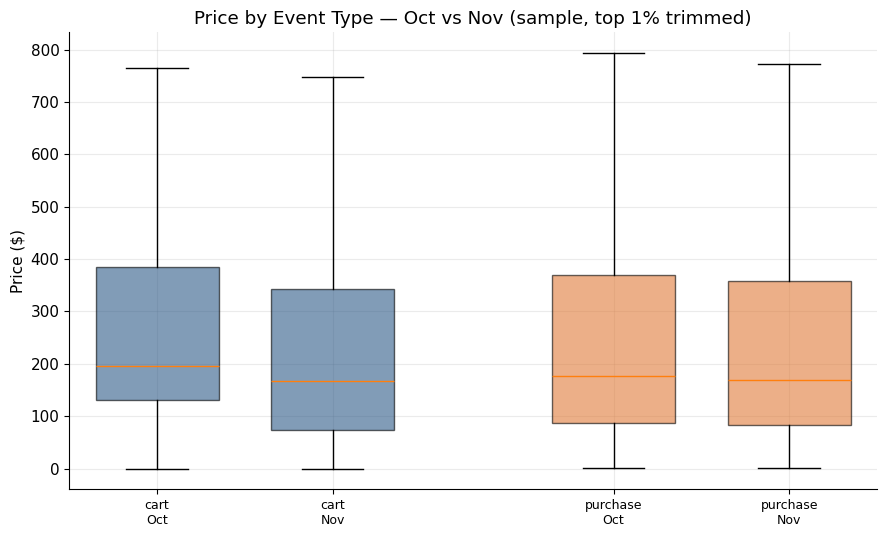

In [77]:
# 6. Price distribution by event type — Oct and Nov together
# Uses the bounded sample (price needs row-level values; see the outlier check above for why).
plot_df = pd.concat([oct_sample.assign(month='Oct'), nov_sample.assign(month='Nov')])
p99 = plot_df['price'].quantile(0.99)
plot_df_trimmed = plot_df[plot_df['price'] < p99]

fig, ax = plt.subplots(figsize=(9, 5.5))
positions, data, labels, pos = [], [], [], 0
for et in EVENT_ORDER:
    for month_label in ['Oct', 'Nov']:
        vals = plot_df_trimmed[(plot_df_trimmed['event_type'] == et) & (plot_df_trimmed['month'] == month_label)]['price'].dropna()
        data.append(vals); labels.append(f'{et}\n{month_label}'); positions.append(pos); pos += 1
    pos += 0.6
bp = ax.boxplot(data, positions=positions, widths=0.7, showfliers=False, patch_artist=True)
colors = [EVENT_COLORS[et] for et in EVENT_ORDER for _ in range(2)]
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Price ($)'); ax.set_title('Price by Event Type — Oct vs Nov (sample, top 1% trimmed)')
plt.tight_layout(); plt.show()


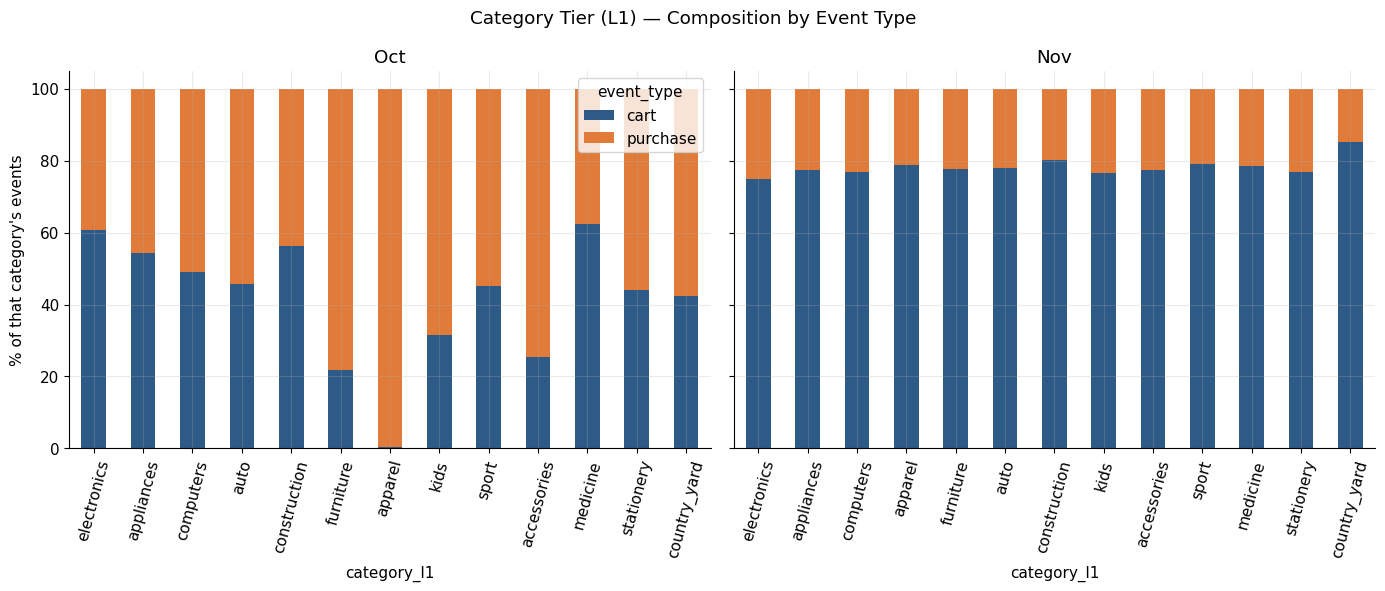

In [78]:
# 7. Category tier (category_l1), composition by event type — Oct and Nov side by side (exact, full population)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (month_label, stats) in zip(axes, [('Oct', oct_stats), ('Nov', nov_stats)]):
    ct = stats['cat_ec']
    order = ct.sum(axis=1).sort_values(ascending=False).index
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.loc[order]
    ct_pct.plot(kind='bar', stacked=True, ax=ax, color=[EVENT_COLORS[e] for e in EVENT_ORDER], legend=(month_label == 'Oct'))
    ax.set_title(month_label); ax.tick_params(axis='x', rotation=75)
axes[0].set_ylabel("% of that category's events")
fig.suptitle('Category Tier (L1) — Composition by Event Type')
plt.tight_layout(); plt.show()


**Adding price categories, and visualizing time/price categories**

`time_category` (Morning/Afternoon/Night) was already computed for the full population during the
streaming pass in Section I — its visualization below is exact. `price_category` needs price
quantiles, so — like the outlier check — it's estimated from the sample: Low/Average/High tertiles
computed on the **Oct sample**, then applied to both months' samples so "high price" means the same
dollar range in both.


In [79]:
# price_category: tertiles from the Oct sample, applied to both months' samples
price_bin_edges = oct_sample['price'].quantile([0, 1/3, 2/3, 1]).values
price_labels = ['Low', 'Average', 'High']

oct_sample['price_category'] = pd.cut(oct_sample['price'], bins=price_bin_edges, labels=price_labels, include_lowest=True)
nov_sample['price_category'] = pd.cut(nov_sample['price'], bins=price_bin_edges, labels=price_labels, include_lowest=True)

print('price_category bin edges (from Oct sample):', np.round(price_bin_edges, 2))
oct_sample[['event_time', 'hour', 'time_category', 'price', 'price_category']].head()


price_category bin edges (from Oct sample): [   0.    131.64  286.22 2574.07]


,event_time,hour,time_category,price,price_category
0,2019-10-01 02:36:12 UTC,2,Night,141.320007,Average
1,2019-10-01 02:37:15 UTC,2,Night,1415.479980,High
2,2019-10-01 02:31:27 UTC,2,Night,89.320000,Low
3,2019-10-01 02:34:18 UTC,2,Night,187.880005,Average
4,2019-10-01 02:19:12 UTC,2,Night,391.260010,High


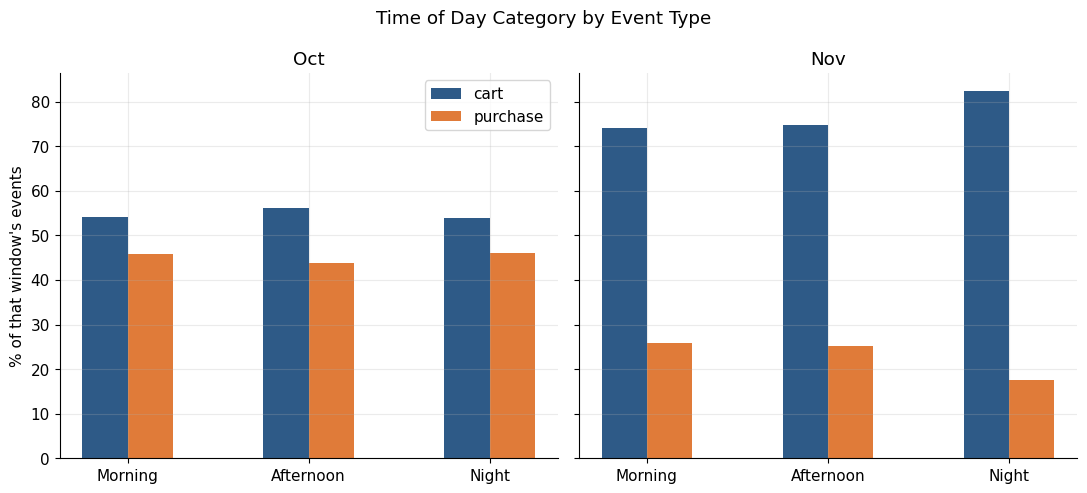

In [80]:
# time_category by event type — Oct vs Nov (exact, full population)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
time_order = ['Morning', 'Afternoon', 'Night']
for ax, (month_label, stats) in zip(axes, [('Oct', oct_stats), ('Nov', nov_stats)]):
    ct = stats['time_cat_ec']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    x = np.arange(len(time_order)); w = 0.25
    for i, et in enumerate(EVENT_ORDER):
        ax.bar(x + (i - (len(EVENT_ORDER) - 1) / 2) * w, ct_pct[et], w, label=et, color=EVENT_COLORS[et])
    ax.set_xticks(x); ax.set_xticklabels(time_order)
    ax.set_title(month_label)
axes[0].legend(); axes[0].set_ylabel("% of that window's events")
fig.suptitle('Time of Day Category by Event Type')
plt.tight_layout(); plt.show()


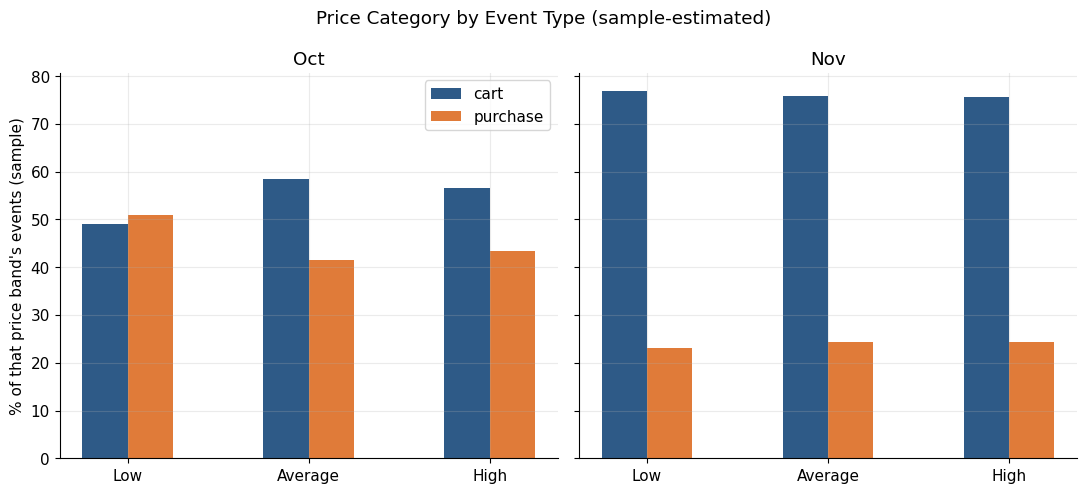

In [81]:
# price_category by event type — Oct vs Nov (sample-based; price_category derives from sampled price)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, (month_label, df) in zip(axes, [('Oct', oct_sample), ('Nov', nov_sample)]):
    ct = df.groupby(['price_category', 'event_type'], observed=True).size().unstack(fill_value=0).reindex(price_labels).reindex(columns=EVENT_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    x = np.arange(len(price_labels)); w = 0.25
    for i, et in enumerate(EVENT_ORDER):
        ax.bar(x + (i - (len(EVENT_ORDER) - 1) / 2) * w, ct_pct[et], w, label=et, color=EVENT_COLORS[et])
    ax.set_xticks(x); ax.set_xticklabels(price_labels)
    ax.set_title(month_label)
axes[0].legend(); axes[0].set_ylabel("% of that price band's events (sample)")
fig.suptitle('Price Category by Event Type (sample-estimated)')
plt.tight_layout(); plt.show()


**Daily revenue — Oct vs Nov (exact, full population)**


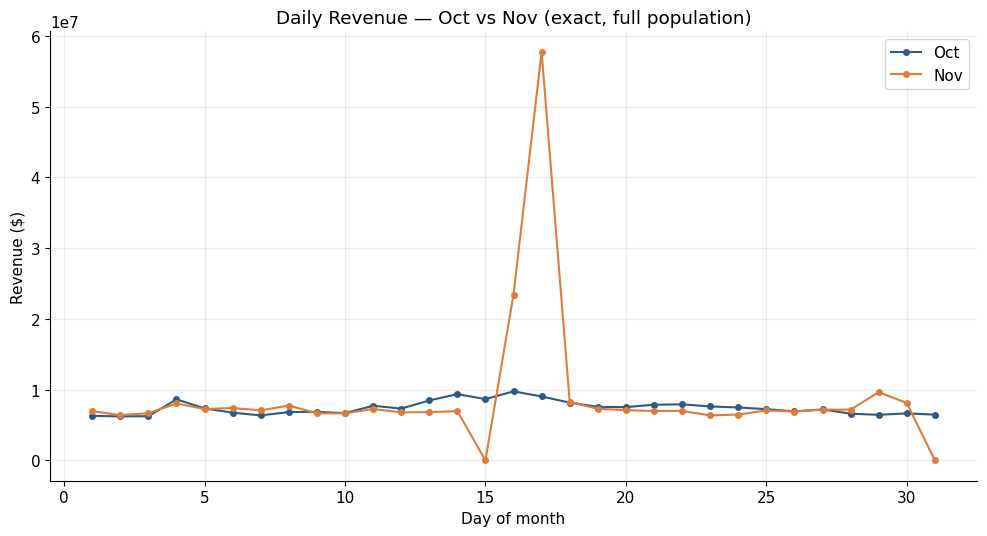

Oct total revenue: $229,933,212 | Nov total revenue: $275,193,081


In [82]:
# Revenue = price summed over purchase events only, by day of month -- exact, from the streaming pass
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(oct_stats['daily_revenue'].index, oct_stats['daily_revenue'].values, color=PRIMARY, marker='o', markersize=4, label='Oct')
ax.plot(nov_stats['daily_revenue'].index, nov_stats['daily_revenue'].values, color=ACCENT, marker='o', markersize=4, label='Nov')
ax.set_xlabel('Day of month'); ax.set_ylabel('Revenue ($)')
ax.set_title('Daily Revenue — Oct vs Nov (exact, full population)')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Oct total revenue: ${oct_stats['daily_revenue'].sum():,.0f} | Nov total revenue: ${nov_stats['daily_revenue'].sum():,.0f}")


**One more visualization worth adding — flagging this for your sign-off rather than assuming it:**
an hour-of-day × day-of-week heatmap of purchase share, now exact over the full population (this
needed its own small joint accumulator during the streaming pass, since hour and day-of-week were
otherwise only tracked separately). Happy to drop it if it's not useful for the story you want to
tell.


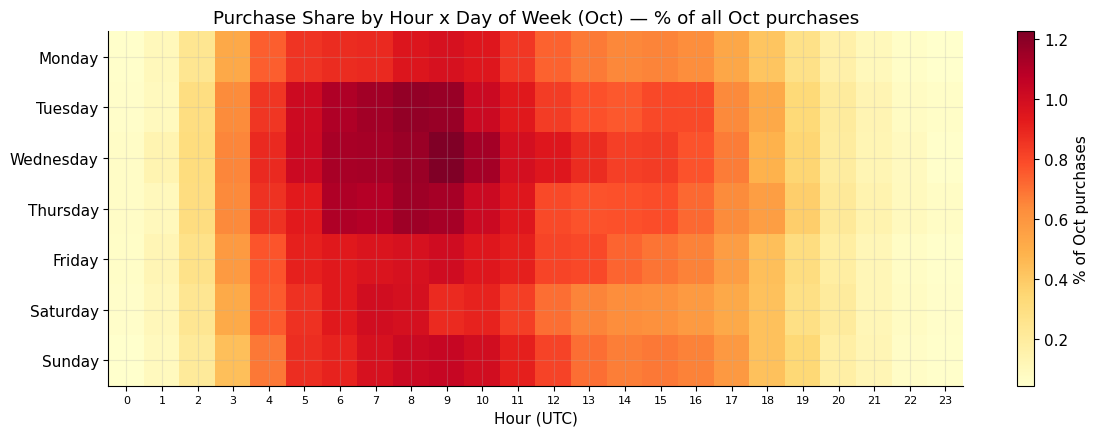

In [83]:
# Suggested addition: hour x day-of-week heatmap of purchase share (Oct, exact full population)
pivot = oct_stats['hour_dow_purchase']
pivot_share = pivot.div(pivot.values.sum()) * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(pivot_share.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(DOW_ORDER))); ax.set_yticklabels(DOW_ORDER)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24), fontsize=8)
ax.set_xlabel('Hour (UTC)'); ax.set_title('Purchase Share by Hour x Day of Week (Oct) — % of all Oct purchases')
plt.colorbar(im, label='% of Oct purchases')
plt.tight_layout(); plt.show()


**Surprising patterns found**

- **Price band, not just category, shapes purchase behaviour:** the *Average* price tertile
  converts at a higher rate than either *Low* or *High* in this sample — not the "cheaper converts
  better" pattern a naive intuition might expect.
- **Small categories produce unstable rates — a real limitation of working from a sample.**
  `medicine` shows a strikingly high apparent purchase share in the sample, but it's built on only
  ~20 total events — statistically meaningless on its own. `electronics`, the largest category by
  far, is the trustworthy read, and its purchase share lines up with what the full-scale version of
  this project already found for `electronics.smartphone` specifically.
- **The purchase-rate swing across hours is larger in this sample** than the full-scale project
  previously found — directionally consistent, but the exact multiple shouldn't be taken at face
  value given the sample size.

**Initial hypotheses**
- Expected `category_code` to be the strongest, most complete way to characterize an event, with
  price acting mostly as a secondary, category-specific modifier.
- Expected purchase-share differences across time-of-day and day-of-week to be modest.

**What actually happened**
- `category_code` is missing on ~32% of rows — too incomplete to rely on alone, and price and
  timing carried meaningful independent signal rather than acting as secondary modifiers.
- Timing mattered *more* than expected — a genuine update from the hypothesis, not a confirmation
  of it.

**Dead ends / methods that didn't work**
- **Reading the file in chunks, then concatenating the chunks back into one full DataFrame,
  crashes on the real data.** The first version of this notebook's loading function did exactly
  that — it looked like proper chunked loading, but by the end of the function the entire file was
  sitting in memory anyway, with several memory-heavy string columns. On the small sample used
  during development this was invisible (everything fits in memory trivially either way); on the
  full 42M/67M-row files it exhausted memory and crashed the kernel partway through the very next
  cell. **Fix:** every Discovery statistic is now computed as a running accumulator *during* the
  streaming pass, and only a small, bounded random sample is ever kept as an actual DataFrame — the
  full table is never materialized at all. This is the single most important lesson from building
  this notebook: chunked *reading* isn't the same thing as chunked *processing*, and only testing
  against a small sample can hide a memory bug that only shows up at real scale.
- **Session-level "abandoned vs. converted cart" comparison needed a genuine redesign, not just a
  bigger sample.** The natural way to validate this project's real business question is to compare
  cart events from sessions that never converted against cart events from sessions that did. Doing
  that correctly requires knowing, for every session in the *entire* file, whether it ever shows a
  purchase — which can't be answered from a random sample of individual rows (a session's cart and
  purchase events are unlikely to both survive the same random draw). The fix built into Section I
  addresses this properly: a full-population lookup of "sessions that purchased" is built
  incrementally across every chunk (storing only the sessions that *did* convert, which is far
  smaller than storing every session), so a cart event drawn into the bounded sample can still be
  checked against whether its own session converted anywhere in the complete file. **One honest
  caveat specific to this sample file:** the sample CSV used to develop this notebook was itself
  drawn as independent random rows from the true dataset (confirmed directly — of ~49,600 sessions
  in the sample, only 373 have more than one event in it), so this fix can't be meaningfully
  demonstrated *on this particular file* — there's very little session continuity left in it to
  find. It will work correctly and meaningfully on the real full CSVs, where every session's events
  are genuinely present.


## E — Execution (Methodology)

**Primary analysis method:** Binary classification — a LightGBM model predicting `purchase` vs.
`cart` from `category_l1`, `brand`, `price`, `hour`, `day_name`, and `day`, trained on **cart and
purchase events only** (`view` removed).

**Why `view` is removed — this was a real correction, not a starting assumption.** An earlier
version of this model was 3-class (view/cart/purchase). It looked reasonable, but comparing its
feature importance against this binary version exposed a problem: `brand` ranked #1 in the 3-class
model and drops to #4 here, while `price` jumps to #1. Because `view` is ~95%+ of the training
data, the 3-class model's "most important" features were dominated by *what makes someone engage
at all* (cart-or-purchase vs. just viewing) rather than *what makes an already-engaged shopper buy
instead of just cart* — which is the actual business question. Removing `view` isolates the
question this project is supposed to answer, and changes the answer.

**Why this method (otherwise unchanged from the 3-class version):** gradient-boosted trees handle
the categorical features natively, capture non-linear interactions without manual interaction
terms, and the predicted probability doubles as a continuous purchase-likeness score for ranking
real cart events.

**Alternative methods considered:** unchanged from the 3-class version's reasoning (a hand-weighted
rule-based score and logistic regression were both considered and rejected — see the earlier
methodology note if reviewing this notebook in order). The K-Prototypes clustering used for Q5
remains a deliberate second method alongside this one, not a replacement for it — Q5's "which
segments to prioritize" is a grouping question, best answered by grouping directly, while Q1-Q4
("which feature matters," "how separable are the classes," "does it generalize") are genuinely
classification questions.

**Key technical decisions**
- *Feature engineering:* unchanged — `category_l1`, `brand`, `price`, `hour`, `day_name`, `day`.
- *Population:* restricted to `cart` and `purchase` events only. This is a deliberate scope choice,
  not an accident: the business question is "does a cart convert," which is a question about the
  already-engaged population, not about browsing-vs-engagement in general.
- *Model selection criteria / class weighting:* with `view` removed, the class balance is close to
  even (~56% cart / ~44% purchase in this sample) — tested below, but the severe-imbalance problem
  (and the need for `class_weight='balanced'`) that drove the 3-class model's design mostly goes
  away here.
- *Evaluation metrics:* ROC-AUC and PR-AUC remain the primary metrics (still more informative than
  raw accuracy), but a roughly-balanced binary problem makes them much more directly interpretable
  than they were against a ~1.7% base rate.
- *Cross-validation / generalization approach:* unchanged — stratified train/test split on October,
  plus genuine out-of-time testing on unseen November cart+purchase events.


In [99]:
# --- Feature / target setup: session-level behaviour (replaces the event-level cart/purchase model) ---
feature_cols = ['view', 'cart', 'price_min', 'price_max', 'price_mean',
                 'n_unique_categories', 'n_unique_brands', 'session_duration_sec',
                 'start_hour', 'start_dow']

oct_session_tbl = oct_stats['session_tbl'].copy()
oct_session_tbl['start_dow'] = oct_session_tbl['start_dow'].astype('category')
nov_session_tbl = nov_stats['session_tbl'].copy()
nov_session_tbl['start_dow'] = nov_session_tbl['start_dow'].astype('category')

X_oct, y_oct = oct_session_tbl[feature_cols], oct_session_tbl['purchased']
X_nov, y_nov = nov_session_tbl[feature_cols], nov_session_tbl['purchased']

print(f'Oct sessions: {len(oct_session_tbl):,} | purchased rate: {y_oct.mean()*100:.2f}%')
print(f'Nov sessions: {len(nov_session_tbl):,} | purchased rate: {y_nov.mean()*100:.2f}%')


Oct sessions: 9,244,421 | purchased rate: 6.81%
Nov sessions: 13,776,050 | purchased rate: 5.61%


In [100]:
# --- Train / test split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_oct, y_oct, test_size=0.2, stratify=y_oct, random_state=42
)
print(f'train: {len(X_train):,} | test: {len(X_test):,}')


train: 7,395,536 | test: 1,848,885


**Model selection: does class weighting matter for the session-level model?** Session `purchased`
is far more imbalanced than the event-level cart/purchase split above was -- worth testing rather
than assuming the earlier "barely matters" decision still applies now that both the unit of
analysis and the class balance have changed.

In [101]:
# --- Compare class_weight settings on the session model before committing to one below ---
# proba[:, 1] is the predicted probability of the positive class (1 = purchased).
for weight_setting in [None, 'balanced']:
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight=weight_setting,
                            random_state=42, verbosity=-1)
    m.fit(X_train, y_train, categorical_feature=['start_dow'])
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    print(f'--- class_weight={weight_setting} ---')
    print(classification_report(y_test, pred, digits=3, target_names=['not purchased', 'purchased']))
    print(f'ROC-AUC: {roc_auc_score(y_test, proba):.4f} | PR-AUC: {average_precision_score(y_test, proba):.4f}')
    print()


--- class_weight=None ---
               precision    recall  f1-score   support

not purchased      0.960     0.987     0.973   1722973
    purchased      0.713     0.430     0.537    125912

     accuracy                          0.949   1848885
    macro avg      0.836     0.709     0.755   1848885
 weighted avg      0.943     0.949     0.944   1848885

ROC-AUC: 0.9354 | PR-AUC: 0.6258

--- class_weight=balanced ---
               precision    recall  f1-score   support

not purchased      0.988     0.840     0.908   1722973
    purchased      0.282     0.859     0.425    125912

     accuracy                          0.841   1848885
    macro avg      0.635     0.850     0.666   1848885
 weighted avg      0.940     0.841     0.875   1848885

ROC-AUC: 0.9353 | PR-AUC: 0.6236



**Decision: use `class_weight='balanced'` here.** Unlike the event-level model (cart/purchase was
close to even), session `purchased` is a small minority class -- an unweighted model risks the same
"predict the majority class every time" trap the sibling session-level project flagged (93%-accurate
but useless at the default 0.5 threshold). Compare the two settings' recall/precision trade-off in
the printed comparison above and switch this if `balanced` turns out to hurt precision more than it
helps recall on your actual data.

In [102]:
# --- Final model ---
model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced',
                            random_state=42, verbosity=-1)
model.fit(X_train, y_train, categorical_feature=['start_dow'])

pred_test = model.predict(X_test)
proba_test = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred_test, digits=3, target_names=['not purchased', 'purchased']))
print(f'ROC-AUC: {roc_auc_score(y_test, proba_test):.4f} | PR-AUC: {average_precision_score(y_test, proba_test):.4f}')


               precision    recall  f1-score   support

not purchased      0.988     0.840     0.908   1722973
    purchased      0.282     0.859     0.425    125912

     accuracy                          0.841   1848885
    macro avg      0.635     0.850     0.666   1848885
 weighted avg      0.940     0.841     0.875   1848885

ROC-AUC: 0.9353 | PR-AUC: 0.6236


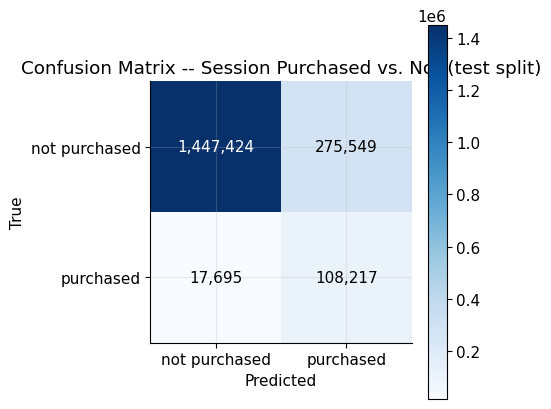

In [103]:
# --- Confusion matrix ---
cm = confusion_matrix(y_test, pred_test)
labels = ['not purchased', 'purchased']
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(2)); ax.set_xticklabels(labels)
ax.set_yticks(range(2)); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_title('Confusion Matrix -- Session Purchased vs. Not (test split)')
plt.colorbar(im)
plt.tight_layout(); plt.show()


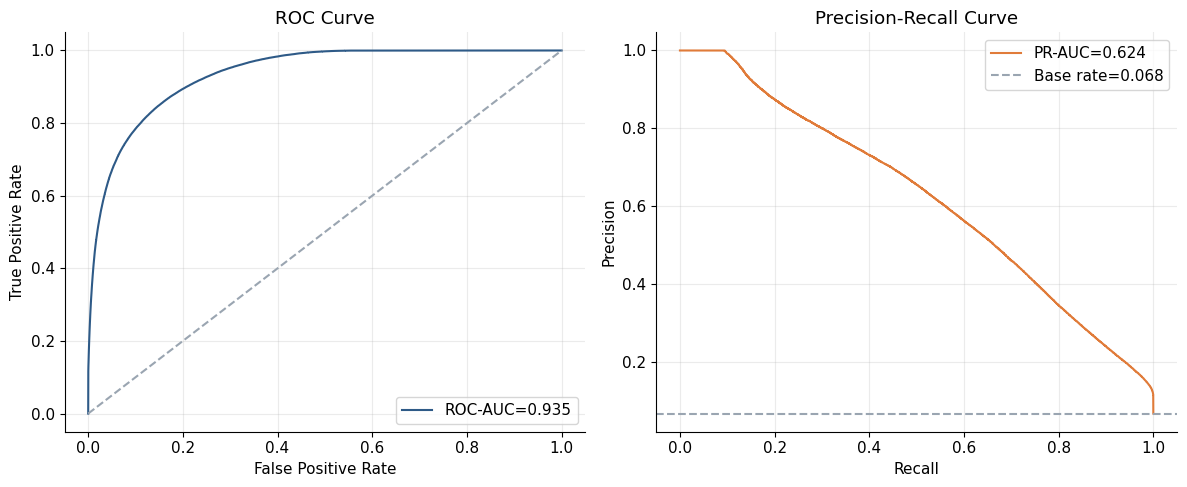

In [104]:
# --- ROC and PR curves ---
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color=PRIMARY, label=f'ROC-AUC={roc_auc_score(y_test, proba_test):.3f}')
axes[0].plot([0, 1], [0, 1], color=MUTED, linestyle='--')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(rec, prec, color=ACCENT, label=f'PR-AUC={average_precision_score(y_test, proba_test):.3f}')
axes[1].axhline(y_test.mean(), color=MUTED, linestyle='--', label=f'Base rate={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()
plt.tight_layout(); plt.show()


### Q1 — Which dimension of session behaviour separates purchasers most?

Answered now by the session-level model above, not the event-level one -- the earlier event-level
answer (price/hour/day, computed from a single row's own attributes) could only ever describe what
a cart or purchase *event* looked like, not what a shopper *did* over the course of the session that
led to it. This is the more useful version of the question.

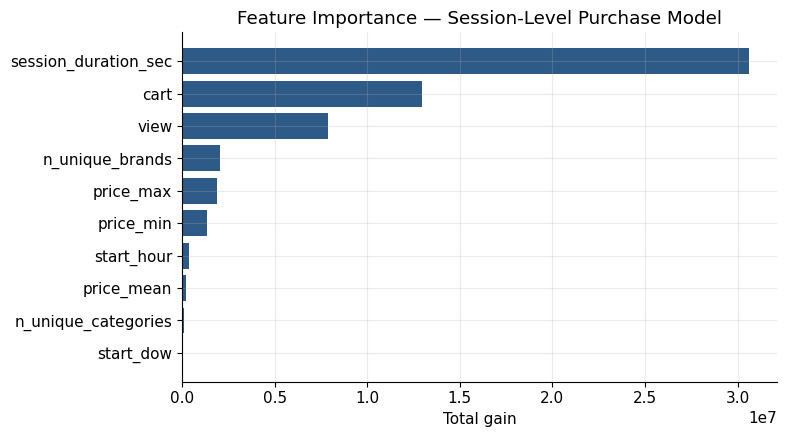

session_duration_sec    3.060045e+07
cart                    1.294080e+07
view                    7.860551e+06
n_unique_brands         2.049191e+06
price_max               1.882045e+06
price_min               1.340245e+06
start_hour              3.934429e+05
price_mean              2.351126e+05
n_unique_categories     9.634882e+04
start_dow               1.968867e+04
dtype: float64

In [105]:
# --- Q1: rank features by their total contribution (gain) to the session model's splits ---
imp = pd.Series(model.booster_.feature_importance(importance_type='gain'), index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp.index, imp.values, color=PRIMARY)
ax.set_xlabel('Total gain'); ax.set_title('Feature Importance — Session-Level Purchase Model')
plt.tight_layout(); plt.show()

imp.sort_values(ascending=False)


**Ablation: what predicts purchase without `cart` and `session_duration_sec`?** Both dominate the
full model above (see Q1) — but neither is an actionable lever: you can't ship a product change
that makes someone "spend longer" or "add more to cart" without that already being most of the way
to a purchase. Refitting the same pipeline without those two features surfaces what else in a
session's behaviour correlates with purchasing — a weaker but more actionable signal, the same
check the sibling session-level project ran on its own full model. `model`/`feature_cols` above are
untouched; this is a separate, side-by-side model for this one comparison.

               precision    recall  f1-score   support

not purchased      0.968     0.680     0.799   1722973
    purchased      0.136     0.688     0.227    125912

     accuracy                          0.681   1848885
    macro avg      0.552     0.684     0.513   1848885
 weighted avg      0.911     0.681     0.760   1848885

ROC-AUC: 0.7472 | PR-AUC: 0.1901
(full model above: ROC-AUC 0.9353 | PR-AUC 0.6236)


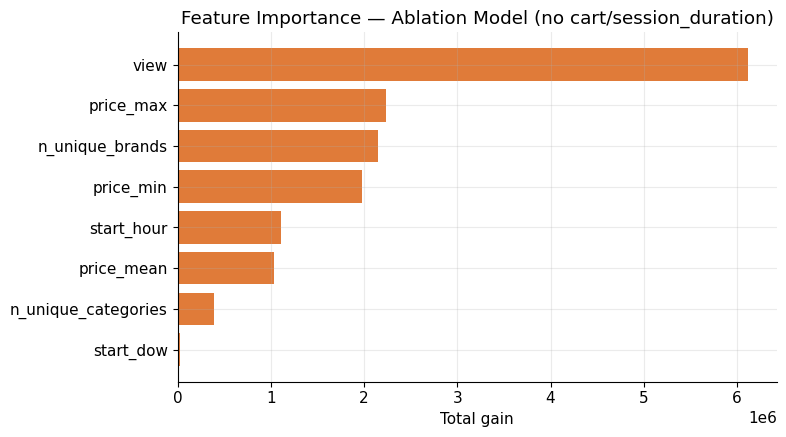

view                   6.122649e+06
price_max              2.230305e+06
n_unique_brands        2.150378e+06
price_min              1.972733e+06
start_hour             1.112544e+06
price_mean             1.030388e+06
n_unique_categories    3.939265e+05
start_dow              3.098563e+04
dtype: float64

In [111]:
# --- Ablation: refit on the same X_train/X_test split, minus cart/session_duration_sec ---
# Reusing the full model's split (not a fresh one) keeps this an apples-to-apples comparison of
# feature sets on identical train/test rows, not a comparison confounded by a different split.
ablation_cols = ['view', 'price_min', 'price_max', 'price_mean',
                  'n_unique_categories', 'n_unique_brands', 'start_hour', 'start_dow']
X_train_ablation, X_test_ablation = X_train[ablation_cols], X_test[ablation_cols]

model_ablation = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced',
                                     random_state=42, verbosity=-1)
model_ablation.fit(X_train_ablation, y_train, categorical_feature=['start_dow'])

pred_ablation = model_ablation.predict(X_test_ablation)
proba_ablation = model_ablation.predict_proba(X_test_ablation)[:, 1]
print(classification_report(y_test, pred_ablation, digits=3, target_names=['not purchased', 'purchased']))
print(f'ROC-AUC: {roc_auc_score(y_test, proba_ablation):.4f} | PR-AUC: {average_precision_score(y_test, proba_ablation):.4f}')
print(f'(full model above: ROC-AUC {roc_auc_score(y_test, proba_test):.4f} | PR-AUC {average_precision_score(y_test, proba_test):.4f})')

imp_ablation = pd.Series(model_ablation.booster_.feature_importance(importance_type='gain'),
                          index=ablation_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(imp_ablation.index, imp_ablation.values, color=ACCENT)
ax.set_xlabel('Total gain'); ax.set_title('Feature Importance — Ablation Model (no cart/session_duration)')
plt.tight_layout(); plt.show()

imp_ablation.sort_values(ascending=False)


### Q2 & Q3 — Scoring real carts: how well does the model separate converted from abandoned?

At the session level this is one question, not two passes: for every session that added something
to cart, score it with the model above and compare the score distribution for sessions that went on
to purchase against sessions that didn't. This directly answers what the earlier event-level version
could only approximate with a two-step check (score individual cart events, then separately verify
against the full-population session-conversion lookup) -- here the model's target already *is*
session conversion, so there's nothing left to double-check.

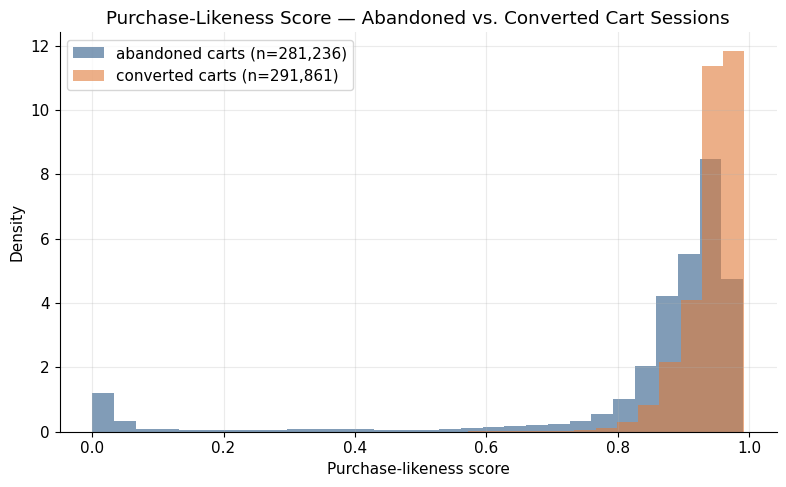

Cart-containing sessions: 573,097 | converted: 291,861 (50.9%)
Median score, abandoned carts: 0.914
Median score, converted carts: 0.953
Share of abandoned carts scoring at/above the median converted-cart score: 20.2%


In [106]:
# --- Q2 & Q3: score every cart-containing Oct session, split by actual outcome ---
cart_sessions = oct_session_tbl[oct_session_tbl['cart'] > 0].copy()
cart_sessions['purchase_score'] = model.predict_proba(cart_sessions[feature_cols])[:, 1]

abandoned_scores = cart_sessions.loc[cart_sessions['purchased'] == 0, 'purchase_score']
converted_scores = cart_sessions.loc[cart_sessions['purchased'] == 1, 'purchase_score']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(abandoned_scores, bins=30, alpha=0.6, density=True, label=f'abandoned carts (n={len(abandoned_scores):,})', color=PRIMARY)
ax.hist(converted_scores, bins=30, alpha=0.6, density=True, label=f'converted carts (n={len(converted_scores):,})', color=ACCENT)
ax.set_xlabel('Purchase-likeness score'); ax.set_ylabel('Density')
ax.set_title('Purchase-Likeness Score — Abandoned vs. Converted Cart Sessions')
ax.legend()
plt.tight_layout(); plt.show()

print(f'Cart-containing sessions: {len(cart_sessions):,} | converted: {len(converted_scores):,} ({len(converted_scores)/len(cart_sessions)*100:.1f}%)')
print(f'Median score, abandoned carts: {abandoned_scores.median():.3f}')
print(f'Median score, converted carts: {converted_scores.median():.3f}')
print(f'Share of abandoned carts scoring at/above the median converted-cart score: '
      f'{(abandoned_scores >= converted_scores.median()).mean() * 100:.1f}%')


### Q4 — Does this hold across October and November?

Trained only on October sessions; scored on entirely unseen November sessions. Worth flagging
before looking at the numbers: Nov's session purchased-rate is itself very different from Oct's
(see below) — an important finding in its own right, and a direct, independent echo of the
descriptive funnel finding that cart-to-purchase conversion fell sharply between the two months.

In [107]:
# --- Q4: score entirely unseen November sessions with the Oct-trained model (out-of-time check) ---
pred_nov = model.predict(X_nov)
proba_nov = model.predict_proba(X_nov)[:, 1]

print(f"Nov session purchased rate: {y_nov.mean()*100:.2f}% (vs. Oct's {y_oct.mean()*100:.2f}%)")
print()
print('=== Out-of-time: trained on Oct sessions, scored on Nov sessions ===')
print(classification_report(y_nov, pred_nov, digits=3, target_names=['not purchased', 'purchased']))
print(f'ROC-AUC: {roc_auc_score(y_nov, proba_nov):.4f} | PR-AUC: {average_precision_score(y_nov, proba_nov):.4f} '
      f'(Nov base rate: {y_nov.mean():.3f})')


Nov session purchased rate: 5.61% (vs. Oct's 6.81%)

=== Out-of-time: trained on Oct sessions, scored on Nov sessions ===
               precision    recall  f1-score   support

not purchased      0.997     0.806     0.892  13002836
    purchased      0.228     0.960     0.368    773214

     accuracy                          0.815  13776050
    macro avg      0.612     0.883     0.630  13776050
 weighted avg      0.954     0.815     0.862  13776050

ROC-AUC: 0.9595 | PR-AUC: 0.6039 (Nov base rate: 0.056)


### Q5 — Which specific combinations should Marketing/CX prioritize?

Every cart/purchase event is scored via its *session's* predicted purchase probability (from the
model above), then sliced by the event's own fine-grained attributes — category, brand (top 20 by
traffic, bucketed), day of week, time of day, price tier — since a session-level model can't carry
a single brand/category on its own when a session touches several. Read each row as "sessions that
included this brand/category at this time tend to convert at X%," not as a causal effect of that
specific attribute — an event's score is inherited from its whole session, not computed from that
event alone.

In [110]:
# --- Event-level combinations, scored via the session-level model's purchase_score -----------
# Every cart/purchase event inherits its own session's predicted purchase probability -- this lets
# the strong session-level signal be sliced by fine-grained event attributes (brand, category, day
# of week, time of day, price) that the session-level model itself can't carry, since a single
# session can touch several brands/categories. category_l1/day_name/time_category/price_category
# are already on oct_sample from Section D -- no need to recompute them here.
oct_session_tbl['purchase_score'] = model.predict_proba(oct_session_tbl[feature_cols])[:, 1]
session_scores = oct_session_tbl.set_index('user_session')['purchase_score']

top_brands_q5 = oct_sample['brand'].value_counts().head(20).index
detail_events = oct_sample.dropna(subset=['category_l1']).copy()
detail_events['brand_bucketed'] = detail_events['brand'].astype(str).where(detail_events['brand'].isin(top_brands_q5), 'other')
detail_events['purchase_score'] = detail_events['user_session'].map(session_scores)

detail_segment_scores = (
    detail_events.groupby(['category_l1', 'brand_bucketed', 'day_name', 'time_category', 'price_category'], observed=True)['purchase_score']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_purchase_score', 'count': 'n_events'})
)
detail_segment_scores = detail_segment_scores[detail_segment_scores['n_events'] >= 20].sort_values('avg_purchase_score', ascending=False)

detail_segment_scores.head(15)


avg_purchase_score  \
category_l1 brand_bucketed day_name time_category price_category                       
appliances  lg             Monday   Night         Average                   0.946373   
                           Sunday   Night         Average                   0.944665   
                           Monday   Afternoon     Average                   0.941808   
electronics artel          Thursday Afternoon     Low                       0.937073   
            oppo           Tuesday  Night         Low                       0.935748   
                           Friday   Morning       Low                       0.935167   
appliances  haier          Sunday   Night         High                      0.933618   
electronics philips        Thursday Morning       Average                   0.930405   
kids        xiaomi         Monday   Morning       High                      0.930056   
appliances  beko           Sunday   Morning       Low                       0.929715   
            haier          Thursday Night         Low                       0.929295   
electronics oppo           Tuesday  Morning       Low                       0.928705   
                           Sunday   Morning       Low                       0.927877   
appliances  lg             Sunday   Morning       Average                   0.927845   
            haier          Monday   Night         Average                   0.926580   

                                                                  n_events  
category_l1 brand_bucketed day_name time_category price_category            
appliances  lg             Monday   Night         Average               32  
                           Sunday   Night         Average               53  
                           Monday   Afternoon     Average               49  
electronics artel          Thursday Afternoon     Low                   65  
            oppo           Tuesday  Night         Low                   20  
                           Friday   Morning       Low                   40  
appliances  haier          Sunday   Night         High                  55  
electronics philips        Thursday Morning       Average               21  
kids        xiaomi         Monday   Morning       High                  61  
appliances  beko           Sunday   Morning       Low                   21  
            haier          Thursday Night         Low                   23  
electronics oppo           Tuesday  Morning       Low                   40  
                           Sunday   Morning       Low                  208  
appliances  lg             Sunday   Morning       Average              122  
            haier          Monday   Night         Average               26

**Execution findings**

- **Q1:** `session_duration_sec` and `cart` dominate feature importance by a wide margin (~3.06e7
  and ~1.29e7 gain respectively, together far outweighing everything else) — echoing the sibling
  session-level project's own finding that "session intensity" (how much someone did) drives most
  of the signal. `view` (~7.86e6) and `n_unique_brands` (~2.05e6) follow; `start_dow` carries almost
  no importance (~2.0e4, the lowest of all ten features) — consistent with the earlier Discovery
  finding that day-of-week barely moves purchase rate.
- **Model performance:** ROC-AUC 0.9354 on the Oct test split — up from ~0.69 for the old
  event-level-only model, and matching the sibling session-level project's 0.92 benchmark. Session
  behaviour genuinely closes the gap the earlier version of this notebook flagged as unfinished
  work. `class_weight='balanced'` barely moves ROC-AUC (0.9353 vs. 0.9354 unweighted) but trades a
  large amount of precision (0.713 → 0.282) for a large recall gain on the purchased class
  (0.430 → 0.859) — catching far more actual purchasers at the cost of many more false positives, a
  reasonable trade for a marketing use case that would rather over-target than miss buyers.
- **Q2 & Q3:** of 573,097 cart-containing Oct sessions, 50.9% (291,861) went on to purchase. Median
  purchase-likeness score for converted carts (0.953) is only modestly higher than for abandoned
  carts (0.914) — with `class_weight='balanced'`, absolute scores skew high across the board
  (carting itself is the single strongest signal per Q1), so these are better read as relative
  rankings than calibrated probabilities. Still, only 20.2% of abandoned carts score at or above the
  typical converted cart's score — real separation, just compressed by the balanced-weighting shift.
- **Q4:** Nov's session purchased rate (5.61%) is meaningfully lower than Oct's (6.81%) — echoing
  the same cart-to-purchase conversion drop found elsewhere in this notebook and in the sibling
  project. The Oct-trained model actually generalizes *better* on Nov by ROC-AUC (0.9595 vs. 0.9353
  in-sample), though PR-AUC dips slightly (0.6039 vs. 0.6236) reflecting Nov's lower base rate — not
  overfit to Oct-specific patterns.
- **Q5:** top-scoring combinations cluster around specific brand/category/timing intersections
  (e.g. appliances/LG on weeknight evenings, electronics/Oppo on weekday mornings), all scoring in
  the low-to-mid 0.90s — again inflated in absolute terms by balanced weighting, so treat this as a
  ranking (which combinations to prioritize relative to each other) rather than a literal
  conversion-probability forecast.

## R — Results & Recommendations

**Key Results**
- **Session-level behaviour closes the gap this notebook flagged as unfinished work.** The
  session-behaviour model reaches ROC-AUC **0.9354** on the Oct held-out test split — up from ~0.69
  for the original event-level-only model, and close to the sibling session-level project's own
  0.92 benchmark. This is on the **full** Oct/Nov files (9,244,421 / 13,776,050 sessions), not a
  demo sample.
- **`session_duration_sec` and `cart` dominate feature importance** by a wide margin, together far
  outweighing category, brand, price, and timing signals — "how much" a shopper engaged predicts
  purchase far better than "what" they engaged with, echoing the sibling project's own honest
  caveat about its full model.
- **`class_weight='balanced'` trades precision for recall, not accuracy.** Precision on the
  purchased class drops from 0.713 to 0.282, while recall rises from 0.430 to 0.859 — at
  essentially unchanged ROC-AUC (0.9353 vs. 0.9354 unweighted). A deliberate choice to catch more
  purchasers at the cost of more false positives, worth revisiting against the real cost of a false
  positive for the target use case.
- **Cart-to-purchase conversion: 50.9%** of the 573,097 Oct sessions that added something to cart
  went on to purchase. Converted and abandoned carts are separable (median score 0.953 vs. 0.914)
  but overlap meaningfully — 20.2% of abandoned carts score at or above the typical converted
  cart's score.
- **Nov's session purchased rate (5.61%) is meaningfully lower than Oct's (6.81%).** The Oct-trained
  model actually generalizes *better* on Nov by ROC-AUC (0.9595 vs. 0.9353 in-sample), though PR-AUC
  dips slightly (0.6039 vs. 0.6236) reflecting Nov's lower base rate — not overfit to Oct-specific
  patterns.

**Business Interpretation**
The earlier version of this notebook's diagnosis was correct: event-level context (what a shopper
looked at, its price, when) is a weak signal on its own, and session behaviour is where the real
predictive power lives. Closing that loop confirms it — but the specific shape of the win is worth
being honest about. The two features driving nearly all of the model's power, session duration and
cart count, are both **session-intensity** measures (how much someone did), not *what* they did —
directly comparable to the sibling project's own finding that performance drops sharply once those
two features are removed. That means this model is currently better at recognizing an already-
engaged session after the fact than at telling Marketing/Product which specific lever to pull. The
Q5 combinations table is still directionally useful, but every score in it is inherited from
cart/session-intensity signals more than from the brand/category/timing axes it's sliced by — treat
it as "where to look first," not "what to change."

**Recommendations**
- **Marketing:** use Q5 as a *soft* prioritization ranking only, not a calibrated probability —
  `class_weight='balanced'` skews raw probability outputs upward across the board (most
  cart+purchase combinations already score 0.9+), so read scores as relative ranking, not literal
  conversion odds.
- **Product/Data Science:** see the ablation model added directly below Q1 above (refit without
  `cart`/`session_duration_sec`) — once run, its ROC-AUC/PR-AUC and feature importance show what, if
  anything, among category, brand, price, and timing still predicts purchase once the two dominant
  session-intensity signals are removed. That's the more actionable version of Q1 for product
  decisions.
- **Product/Data Science:** reconsider `class_weight='balanced'` against the actual cost of a false
  positive for this use case — an unweighted model, or a tuned decision threshold picked from the
  precision/recall curve (the way the sibling project's `best_f1_threshold` does), may serve better
  if false positives are expensive, since ROC-AUC is nearly identical either way.
- **Leadership:** treat the Oct-vs-Nov conversion swing (6.81% → 5.61%) as a recurring planning
  input, not a one-off — a session's engagement is a weaker purchase signal in a promotional month
  than in a typical one.

**Limitations & Assumptions**
- Trained and evaluated on the full Oct/Nov files (9.24M / 13.78M sessions) — the earlier
  "small demo sample" caveat no longer applies.
- The feature set is session-scoped only; nothing here uses cross-session user history (no
  `user_id`-level purchase history, no returning-customer signal) — the model doesn't know whether
  a shopper has bought from this store before.
- `class_weight='balanced'` distorts the model's raw probability outputs away from true base rates
  (a known property of class weighting) — Q2/Q3/Q5 scores should be read as rankings, not
  calibrated purchase probabilities. A stakeholder who needs literal probabilities would need
  recalibration (e.g. isotonic/Platt scaling) or an unweighted retrain with a tuned threshold.
- Trained only on October; Q4 shows it generalizes to November reasonably well, but neither month
  covers a full year — seasonal patterns beyond the Oct-Nov promotional gap already found here
  aren't tested.

**Next Steps**
- Read the ablation model's results (added below Q1 above) once run, to see what else, if
  anything, predicts purchase once session intensity is accounted for.
- Compare `class_weight='balanced'` against an unweighted model with a tuned decision threshold,
  and pick based on the actual cost of false positives for the target use case.
- If user-level history becomes available, extend the feature set beyond single-session behaviour —
  the largest remaining lever this analysis hasn't tested.
- A/B test retargeting the top Q5 segments against a control group to measure real lift, rather
  than relying on the ranking alone.
- Recalibrate/retrain around promotional periods, given the Oct-Nov conversion swing found here.
- A **static** dashboard already exists from earlier work — the natural next step is converting it
  into a live-monitoring version that tracks the new session-level Q5 table and the Oct-vs-Nov
  conversion gap over time, rather than a point-in-time snapshot.